# 07 — ResNet50 Initial Transfer Learning

**Project:** Smart Waste Classification System  
**Dataset:** TrashNet  
**Framework:** PyTorch  
**Author:** Syed Soban Mudassar

---

## Purpose

This notebook performs the project's first transfer-learning experiment using
ResNet50 pretrained on ImageNet.

The original ResNet50 classifier predicts 1,000 ImageNet classes. It is
replaced with a new classifier that predicts the six TrashNet categories:

1. cardboard
2. glass
3. metal
4. paper
5. plastic
6. trash

During this initial experiment, the pretrained feature extractor remains
frozen and only the replacement classifier is trained.

This approach:

- preserves pretrained visual features,
- reduces training time,
- lowers the risk of overfitting,
- establishes an initial ResNet50 result before fine-tuning.

Fine-tuning of selected pretrained layers will be performed during the model
optimization stage.

## Manual Alignment

This notebook contributes to the following client requirements:

| Requirement | Implementation |
|---|---|
| Use transfer learning | ImageNet-pretrained ResNet50 |
| Evaluate required architectures | First of four required pretrained models |
| Explain frozen layers | ResNet50 backbone remains frozen |
| Explain learning-rate strategy | Classifier uses an initial learning rate of 0.001 |
| Handle class imbalance | Weighted cross-entropy from training labels |
| Prevent leakage | Training, validation, and test splits remain separate |
| Save trained model | Best validation-loss checkpoint |
| Report mandatory metrics | Accuracy, precision, recall, F1, ROC-AUC, confusion matrix and per-class accuracy |
| Maintain modular source code | Notebook imports reusable source modules |

##  ResNet50 Architecture

ResNet50 is a deep convolutional neural network containing residual
connections.

A traditional deep network can become difficult to optimize because gradients
must pass through many layers.

ResNet introduces shortcut connections:

```text
input
  ├───────────────┐
  ↓               │
convolution block │
  ↓               │
learned features  │
  ↓               │
addition ←────────┘

In [39]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)

Python executable: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cpu


In [40]:
from src.class_imbalance import get_training_class_weights
from src.data_loaders import create_data_loaders
from src.evaluate import evaluate_model
from src.models.transfer_learning import (
    count_parameters,
    create_transfer_learning_model,
    get_trainable_parameter_names,
)
from src.train import (
    create_classification_loss,
    select_device,
    set_random_seed,
    train_model,
)

print("Reusable project modules imported successfully.")

Reusable project modules imported successfully.


In [41]:
def find_project_root(start_path: Path) -> Path:
    """Locate the project root using known folders and files."""

    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "requirements.txt").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification


In [42]:
RANDOM_SEED = 42

MODEL_NAME = "resnet50"
TRAINING_MODE = "classifier"

BATCH_SIZE = 8
NUMBER_OF_WORKERS = 0

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

MAXIMUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
MINIMUM_IMPROVEMENT = 0.001

DROPOUT_PROBABILITY = 0.20

SCHEDULER_STEP_SIZE = 4
SCHEDULER_GAMMA = 0.50

DEVICE = select_device("cpu")

print("Model:", MODEL_NAME)
print("Training mode:", TRAINING_MODE)
print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAXIMUM_EPOCHS)

Model: resnet50
Training mode: classifier
Device: cpu
Batch size: 8
Maximum epochs: 10


In [43]:
PROCESSED_DIRECTORY = (
    PROJECT_ROOT / "data" / "processed"
)

TRAIN_DIRECTORY = PROCESSED_DIRECTORY / "train"
VALIDATION_DIRECTORY = (
    PROCESSED_DIRECTORY / "validation"
)
TEST_DIRECTORY = PROCESSED_DIRECTORY / "test"

MODEL_DIRECTORY = PROJECT_ROOT / "models"

REPORT_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "transfer_learning"
    / "resnet50_initial"
)

CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "resnet50_classifier_best.pt"
)

CONFIGURATION_PATH = (
    REPORT_DIRECTORY
    / "experiment_configuration.json"
)

HISTORY_PATH = (
    REPORT_DIRECTORY
    / "training_history.json"
)

METRICS_PATH = (
    REPORT_DIRECTORY
    / "evaluation_metrics.json"
)

MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

for directory in [
    TRAIN_DIRECTORY,
    VALIDATION_DIRECTORY,
    TEST_DIRECTORY,
]:
    assert directory.exists(), (
        f"Missing directory: {directory}"
    )

print("Checkpoint:", CHECKPOINT_PATH)
print("Reports:", REPORT_DIRECTORY)

Checkpoint: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\resnet50_classifier_best.pt
Reports: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial


In [44]:
set_random_seed(RANDOM_SEED)

print("Random seed configured:", RANDOM_SEED)

Random seed configured: 42


In [45]:
data_bundle = create_data_loaders(
    train_directory=TRAIN_DIRECTORY,
    validation_directory=VALIDATION_DIRECTORY,
    test_directory=TEST_DIRECTORY,
    batch_size=BATCH_SIZE,
    number_of_workers=NUMBER_OF_WORKERS,
    random_seed=RANDOM_SEED,
)

print("Classes:", data_bundle.class_names)
print("Class mapping:", data_bundle.class_to_idx)

print("\nDataset sizes:")
print("Training:", len(data_bundle.train_dataset))
print("Validation:", len(data_bundle.validation_dataset))
print("Test:", len(data_bundle.test_dataset))

Classes: ('cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash')
Class mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Dataset sizes:
Training: 1762
Validation: 378
Test: 381


In [46]:
sample_images, sample_labels = next(
    iter(data_bundle.train_loader)
)

print("Image batch:", sample_images.shape)
print("Labels:", sample_labels.shape)
print("Image dtype:", sample_images.dtype)

assert sample_images.shape == (
    BATCH_SIZE,
    3,
    224,
    224,
)

KeyboardInterrupt: 

In [ ]:
class_weights, weight_class_mapping = (
    get_training_class_weights(
        TRAIN_DIRECTORY
    )
)

assert (
    weight_class_mapping
    == data_bundle.class_to_idx
)

class_weight_dataframe = pd.DataFrame(
    {
        "class_name": data_bundle.class_names,
        "class_weight": class_weights.numpy(),
    }
)

class_weight_dataframe

,class_name,class_weight
0,cardboard,0.823770
1,glass,0.667538
2,metal,0.812249
3,paper,0.559767
4,plastic,0.691379
5,trash,2.445297


In [ ]:
model = create_transfer_learning_model(
    model_name=MODEL_NAME,
    number_of_classes=len(
        data_bundle.class_names
    ),
    pretrained=True,
    dropout_probability=DROPOUT_PROBABILITY,
    training_mode=TRAINING_MODE,
)

total_parameters, trainable_parameters = (
    count_parameters(model)
)

print(model.fc)

print("\nTotal parameters:")
print(f"{total_parameters:,}")

print("\nTrainable parameters:")
print(f"{trainable_parameters:,}")

print("\nFrozen parameters:")
print(
    f"{total_parameters - trainable_parameters:,}"
)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=6, bias=True)
)

Total parameters:
23,520,326

Trainable parameters:
12,294

Frozen parameters:
23,508,032


In [ ]:
trainable_parameter_names = (
    get_trainable_parameter_names(model)
)

print("Trainable parameter names:")

for parameter_name in trainable_parameter_names:
    print("-", parameter_name)

assert trainable_parameter_names
assert all(
    parameter_name.startswith("fc.")
    for parameter_name
    in trainable_parameter_names
)

print(
    "\nOnly the replacement classifier is trainable."
)

Trainable parameter names:
- fc.1.weight
- fc.1.bias

Only the replacement classifier is trainable.


In [ ]:
model = model.to(DEVICE)
model.eval()

with torch.no_grad():
    sample_outputs = model(
        sample_images.to(DEVICE)
    )

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)

assert sample_outputs.shape == (
    BATCH_SIZE,
    len(data_bundle.class_names),
)

Input shape: torch.Size([8, 3, 224, 224])
Output shape: torch.Size([8, 6])


In [ ]:
criterion = create_classification_loss(
    class_weights=class_weights,
    device=DEVICE,
)

trainable_parameters_only = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    trainable_parameters_only,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(
    optimizer,
    step_size=SCHEDULER_STEP_SIZE,
    gamma=SCHEDULER_GAMMA,
)

print("Loss:", criterion)
print("Trainable tensors:", len(trainable_parameters_only))
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Trainable tensors: 2
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
experiment_configuration = {
    "model_name": MODEL_NAME,
    "training_mode": TRAINING_MODE,
    "pretrained": True,
    "random_seed": RANDOM_SEED,
    "device": str(DEVICE),
    "batch_size": BATCH_SIZE,
    "number_of_workers": NUMBER_OF_WORKERS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "minimum_improvement": MINIMUM_IMPROVEMENT,
    "dropout_probability": DROPOUT_PROBABILITY,
    "scheduler_step_size": SCHEDULER_STEP_SIZE,
    "scheduler_gamma": SCHEDULER_GAMMA,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
    "class_names": list(data_bundle.class_names),
    "class_weights": [
        float(weight)
        for weight in class_weights
    ],
}

CONFIGURATION_PATH.write_text(
    json.dumps(
        experiment_configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print("Configuration saved:")
print(CONFIGURATION_PATH)

Configuration saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\experiment_configuration.json


##  Initial ResNet50 Training

The following experiment trains only the replacement classifier.

The pretrained ResNet50 feature extractor remains frozen throughout this
notebook.

### Learning-rate strategy

The classifier begins with a learning rate of `0.001`.

A step scheduler reduces the rate by half after every four epochs.

This allows:

- larger classifier updates during early epochs,
- smaller refinements later,
- reduced oscillation near a useful solution.

During future fine-tuning, the learning rate will be reduced because pretrained
feature layers require smaller, more cautious updates.

## Train ResNet50

In [ ]:
training_history = train_model(
    model=model,
    train_loader=data_bundle.train_loader,
    validation_loader=(
        data_bundle.validation_loader
    ),
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    number_of_epochs=MAXIMUM_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    class_names=data_bundle.class_names,
    model_name=MODEL_NAME,
    early_stopping_patience=(
        EARLY_STOPPING_PATIENCE
    ),
    minimum_improvement=MINIMUM_IMPROVEMENT,
    scheduler=scheduler,
)

print("\nTraining completed.")
print("Best epoch:", training_history.best_epoch)
print(
    "Best validation loss:",
    training_history.best_validation_loss,
)
print(
    "Stopped early:",
    training_history.stopped_early,
)

Epoch 01/10 | Train loss: 1.2400 | Train accuracy: 0.6271 | Validation loss: 0.8395 | Validation accuracy: 0.7884 | LR: 0.001000
Epoch 02/10 | Train loss: 0.8482 | Train accuracy: 0.7616 | Validation loss: 0.6938 | Validation accuracy: 0.8042 | LR: 0.001000
Epoch 03/10 | Train loss: 0.7121 | Train accuracy: 0.7832 | Validation loss: 0.6208 | Validation accuracy: 0.8095 | LR: 0.001000
Epoch 04/10 | Train loss: 0.6682 | Train accuracy: 0.7872 | Validation loss: 0.5579 | Validation accuracy: 0.8122 | LR: 0.001000
Epoch 05/10 | Train loss: 0.5990 | Train accuracy: 0.8309 | Validation loss: 0.5497 | Validation accuracy: 0.8280 | LR: 0.000500
Epoch 06/10 | Train loss: 0.5661 | Train accuracy: 0.8207 | Validation loss: 0.5434 | Validation accuracy: 0.8148 | LR: 0.000500
Epoch 07/10 | Train loss: 0.5369 | Train accuracy: 0.8388 | Validation loss: 0.5037 | Validation accuracy: 0.8228 | LR: 0.000500
Epoch 08/10 | Train loss: 0.5138 | Train accuracy: 0.8428 | Validation loss: 0.4662 | Validation 

In [ ]:
history_dataframe = pd.DataFrame(
    {
        "epoch": range(
            1,
            len(training_history.train_loss) + 1,
        ),
        "train_loss": training_history.train_loss,
        "validation_loss": training_history.validation_loss,
        "train_accuracy": training_history.train_accuracy,
        "validation_accuracy": training_history.validation_accuracy,
        "learning_rate": training_history.learning_rates,
    }
)

history_dataframe

,epoch,train_loss,validation_loss,train_accuracy,validation_accuracy,learning_rate
0,1,1.239961,0.839531,0.627128,0.788360,0.00100
1,2,0.848228,0.693818,0.761635,0.804233,0.00100
2,3,0.712066,0.620758,0.783201,0.809524,0.00100
3,4,0.668191,0.557890,0.787174,0.812169,0.00100
4,5,0.599003,0.549674,0.830874,0.828042,0.00050
5,6,0.566078,0.543367,0.820658,0.814815,0.00050
6,7,0.536885,0.503698,0.838820,0.822751,0.00050
7,8,0.513771,0.466166,0.842792,0.843915,0.00050
8,9,0.515296,0.500204,0.840522,0.822751,0.00025
9,10,0.503127,0.486342,0.838820,0.828042,0.00025


In [ ]:
HISTORY_PATH.write_text(
    json.dumps(
        training_history.to_dict(),
        indent=2,
    ),
    encoding="utf-8",
)

print("Training history saved:")
print(HISTORY_PATH)

print("Best checkpoint saved:")
print(CHECKPOINT_PATH)

Training history saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\training_history.json
Best checkpoint saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\resnet50_classifier_best.pt


In [ ]:
HISTORY_PATH.write_text(
    json.dumps(
        training_history.to_dict(),
        indent=2,
    ),
    encoding="utf-8",
)

print("Training history saved:")
print(HISTORY_PATH)

print("Best checkpoint saved:")
print(CHECKPOINT_PATH)

Training history saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\training_history.json
Best checkpoint saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\resnet50_classifier_best.pt


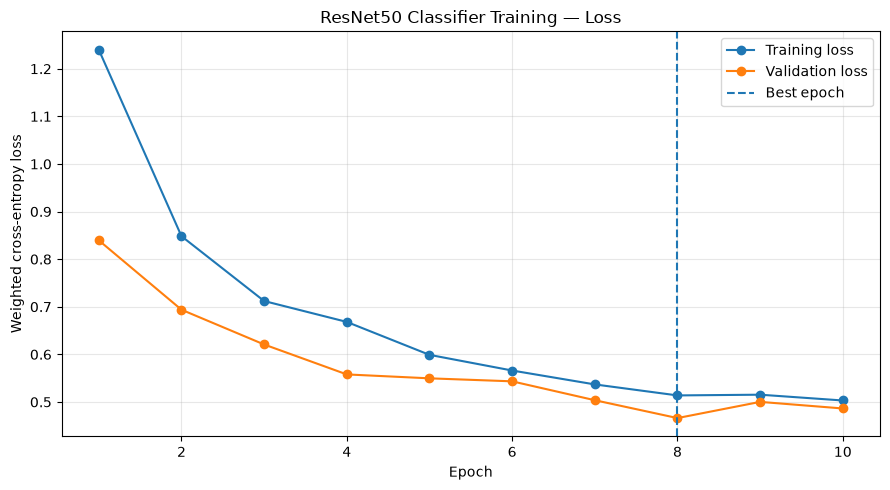

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["train_loss"],
    marker="o",
    label="Training loss",
)

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["validation_loss"],
    marker="o",
    label="Validation loss",
)

if training_history.best_epoch is not None:
    plt.axvline(
        training_history.best_epoch,
        linestyle="--",
        label="Best epoch",
    )

plt.title("ResNet50 Classifier Training — Loss")
plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

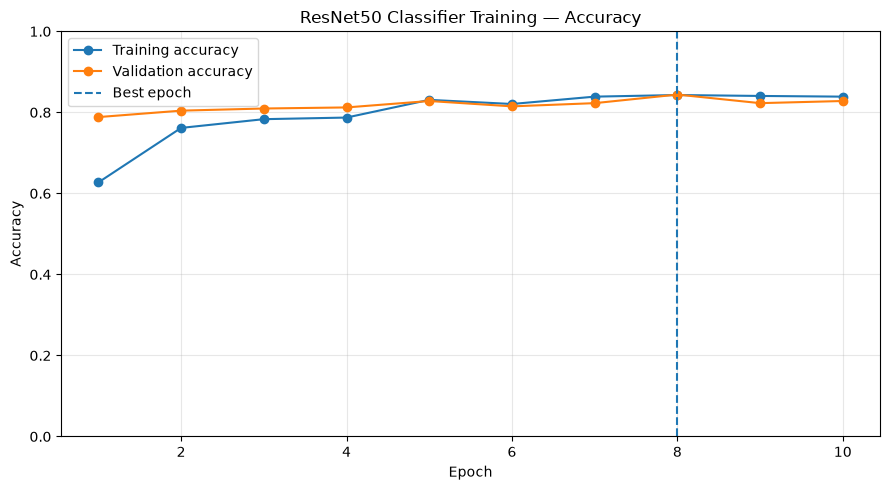

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["train_accuracy"],
    marker="o",
    label="Training accuracy",
)

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["validation_accuracy"],
    marker="o",
    label="Validation accuracy",
)

if training_history.best_epoch is not None:
    plt.axvline(
        training_history.best_epoch,
        linestyle="--",
        label="Best epoch",
    )

plt.title("ResNet50 Classifier Training — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##  Best-Checkpoint Evaluation

The model remaining in memory after the final epoch is not necessarily the
best-performing version.

During training, the project saved a checkpoint whenever validation loss
improved. A fresh ResNet50 instance will therefore be created and populated
with the best saved parameters.

This prevents accidental evaluation of:

- the final epoch instead of the best epoch,
- an altered in-memory model,
- continued training after the controlled experiment.

The test set was not used for optimization, learning-rate adjustment, early
stopping, or checkpoint selection.

In [ ]:
assert CHECKPOINT_PATH.exists(), (
    f"Checkpoint does not exist: {CHECKPOINT_PATH}"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

print("Checkpoint keys:")
print(checkpoint.keys())

print("\nModel name:", checkpoint["model_name"])
print("Saved epoch:", checkpoint["epoch"])
print(
    "Saved validation loss:",
    checkpoint["validation_loss"],
)
print(
    "Saved validation accuracy:",
    checkpoint["validation_accuracy"],
)
print(
    "Saved class names:",
    checkpoint["class_names"],
)

Checkpoint keys:
dict_keys(['model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'validation_loss', 'validation_accuracy', 'class_names', 'training_history'])

Model name: resnet50
Saved epoch: 8
Saved validation loss: 0.4661657491689006
Saved validation accuracy: 0.843915343915344
Saved class names: ('cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash')


In [ ]:
checkpoint_class_names = tuple(
    checkpoint["class_names"]
)

assert checkpoint["model_name"] == MODEL_NAME, (
    "Checkpoint model name does not match ResNet50."
)

assert checkpoint_class_names == data_bundle.class_names, (
    "Checkpoint class order does not match "
    "the current dataset class order."
)

assert checkpoint["epoch"] == training_history.best_epoch, (
    "Checkpoint epoch does not match "
    "the recorded best epoch."
)

print("Checkpoint compatibility checks passed.")

Checkpoint compatibility checks passed.


In [ ]:
best_model = create_transfer_learning_model(
    model_name=MODEL_NAME,
    number_of_classes=len(
        checkpoint_class_names
    ),
    pretrained=False,
    dropout_probability=DROPOUT_PROBABILITY,
    training_mode=TRAINING_MODE,
)

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model = best_model.to(DEVICE)
best_model.eval()

print("Best ResNet50 checkpoint loaded successfully.")

Best ResNet50 checkpoint loaded successfully.


##  Validation Evaluation

The validation set was used to monitor generalization and select the best
checkpoint.

Its results are useful for development analysis, but the validation set is not
the final unbiased performance estimate because it influenced model selection.

In [51]:
validation_predictions, validation_metrics = evaluate_model(
    model=best_model,
    data_loader=data_bundle.validation_loader,
    class_names=data_bundle.class_names,
    device=DEVICE,
)

print("Validation evaluation completed.")
print(
    "Validation samples:",
    validation_metrics.sample_count,
)

Validation evaluation completed.
Validation samples: 378


##  Test Evaluation

The test split is now evaluated using the saved best checkpoint.

This produces the initial ResNet50 test result used in the Week 4 model
comparison.

The test result must not be used to alter this trained model.

In [50]:
test_predictions, test_metrics = evaluate_model(
    model=best_model,
    data_loader=data_bundle.test_loader,
    class_names=data_bundle.class_names,
    device=DEVICE,
)

print("Test evaluation completed.")
print("Test samples:", test_metrics.sample_count)

Test evaluation completed.
Test samples: 381


In [57]:
test_sample_paths = [
    sample_path
    for sample_path, _ in data_bundle.test_dataset.samples
]

assert len(test_sample_paths) == test_predictions.sample_count
assert len(test_predictions.true_labels) == test_predictions.sample_count
assert len(test_predictions.predicted_labels) == test_predictions.sample_count
assert len(test_predictions.probabilities) == test_predictions.sample_count

prediction_records = []

for sample_index, image_path in enumerate(test_sample_paths):
    true_index = int(
        test_predictions.true_labels[sample_index]
    )

    predicted_index = int(
        test_predictions.predicted_labels[sample_index]
    )

    predicted_confidence = float(
        test_predictions.probabilities[
            sample_index,
            predicted_index,
        ]
    )

    true_class_probability = float(
        test_predictions.probabilities[
            sample_index,
            true_index,
        ]
    )

    prediction_records.append(
        {
            "image_path": str(image_path),
            "true_index": true_index,
            "true_class": data_bundle.class_names[
                true_index
            ],
            "predicted_index": predicted_index,
            "predicted_class": data_bundle.class_names[
                predicted_index
            ],
            "predicted_confidence": predicted_confidence,
            "true_class_probability": true_class_probability,
            "correct": true_index == predicted_index,
        }
    )

test_prediction_dataframe = pd.DataFrame(
    prediction_records
)

print(
    "Number of test predictions:",
    len(test_prediction_dataframe),
)

test_prediction_dataframe.head()

Number of test predictions: 381


,image_path,true_index,true_class,predicted_index,predicted_class,predicted_confidence,true_class_probability,correct
0,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,0,cardboard,0.774381,0.774381,True
1,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,0,cardboard,0.906454,0.906454,True
2,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,0,cardboard,0.988346,0.988346,True
3,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,2,metal,0.530927,0.041102,False
4,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,0,cardboard,0.775119,0.775119,True


In [ ]:
overall_metrics_dataframe = pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": validation_metrics.accuracy,
            "macro_precision": (
                validation_metrics.macro_precision
            ),
            "macro_recall": (
                validation_metrics.macro_recall
            ),
            "macro_f1": validation_metrics.macro_f1,
            "weighted_precision": (
                validation_metrics.weighted_precision
            ),
            "weighted_recall": (
                validation_metrics.weighted_recall
            ),
            "weighted_f1": (
                validation_metrics.weighted_f1
            ),
            "roc_auc_ovr_macro": (
                validation_metrics.roc_auc_ovr_macro
            ),
            "average_inference_ms": (
                validation_metrics
                .average_inference_time_seconds
                * 1000
            ),
        },
        {
            "split": "test",
            "accuracy": test_metrics.accuracy,
            "macro_precision": (
                test_metrics.macro_precision
            ),
            "macro_recall": test_metrics.macro_recall,
            "macro_f1": test_metrics.macro_f1,
            "weighted_precision": (
                test_metrics.weighted_precision
            ),
            "weighted_recall": (
                test_metrics.weighted_recall
            ),
            "weighted_f1": test_metrics.weighted_f1,
            "roc_auc_ovr_macro": (
                test_metrics.roc_auc_ovr_macro
            ),
            "average_inference_ms": (
                test_metrics
                .average_inference_time_seconds
                * 1000
            ),
        },
    ]
)

overall_metrics_dataframe.round(4)

,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr_macro,average_inference_ms
0,validation,0.8439,0.8327,0.8382,0.8269,0.8610,0.8439,0.8448,0.9799,115.9553
1,test,0.8766,0.8532,0.8614,0.8520,0.8878,0.8766,0.8781,0.9879,118.4426


##  Overall ResNet50 Interpretation

The initial frozen-backbone ResNet50 achieved a **test accuracy of 87.66%**.

Its **macro F1-score was 85.20%**, while its **weighted F1-score was 87.81%**. The model also achieved a strong **macro one-vs-rest ROC-AUC of 98.79%**, indicating excellent separation among the six waste categories across different confidence thresholds.

### Validation performance

| Metric | Validation result |
|---|---:|
| Accuracy | **84.39%** |
| Macro precision | **83.27%** |
| Macro recall | **83.82%** |
| Macro F1-score | **82.69%** |
| Weighted precision | **86.10%** |
| Weighted recall | **84.39%** |
| Weighted F1-score | **84.48%** |
| Macro ROC-AUC | **97.99%** |
| Average inference time | **approximately 115.96 ms/image** |

### Test performance

| Metric | Test result |
|---|---:|
| Accuracy | **87.66%** |
| Macro precision | **85.32%** |
| Macro recall | **86.14%** |
| Macro F1-score | **85.20%** |
| Weighted precision | **88.78%** |
| Weighted recall | **87.66%** |
| Weighted F1-score | **87.81%** |
| Macro ROC-AUC | **98.79%** |
| Average inference time | **approximately 118.44 ms/image** |

### Macro versus weighted results

The weighted F1-score was **2.61 percentage points higher** than the macro F1-score:

```text
87.81% − 85.20% = 2.61 percentage points

In [ ]:
test_report = test_metrics.classification_report

per_class_records = []

for class_name in data_bundle.class_names:
    class_report = test_report[class_name]

    per_class_records.append(
        {
            "class_name": class_name,
            "precision": class_report["precision"],
            "recall": class_report["recall"],
            "f1_score": class_report["f1-score"],
            "support": int(class_report["support"]),
            "class_accuracy": (
                test_metrics
                .per_class_accuracy[class_name]
            ),
        }
    )

per_class_dataframe = pd.DataFrame(
    per_class_records
)

per_class_dataframe.round(4)

,class_name,precision,recall,f1_score,support,class_accuracy
0,cardboard,0.9600,0.7869,0.8649,61,0.7869
1,glass,0.9565,0.8800,0.9167,75,0.8800
2,metal,0.8133,0.9839,0.8905,62,0.9839
3,paper,0.8737,0.9222,0.8973,90,0.9222
4,plastic,0.9231,0.8333,0.8759,72,0.8333
5,trash,0.5926,0.7619,0.6667,21,0.7619


### Per-Class Accuracy Interpretation

The ResNet50 model achieved strong test performance across most waste categories, although the results were not completely uniform.

| Waste class | Precision | Recall | F1-score | Support | Per-class accuracy |
|---|---:|---:|---:|---:|---:|
| Cardboard | **96.00%** | **78.69%** | **86.49%** | 61 | **78.69%** |
| Glass | **95.65%** | **88.00%** | **91.67%** | 75 | **88.00%** |
| Metal | **81.33%** | **98.39%** | **89.05%** | 62 | **98.39%** |
| Paper | **87.37%** | **92.22%** | **89.73%** | 90 | **92.22%** |
| Plastic | **92.31%** | **83.33%** | **87.59%** | 72 | **83.33%** |
| Trash | **59.26%** | **76.19%** | **66.67%** | 21 | **76.19%** |

---

### Strongest class

The strongest class was **metal**, with a per-class accuracy and recall of **98.39%**.

This means the model correctly identified approximately 98 out of every 100 metal images in the test set. Its F1-score of **89.05%** also indicates a strong balance between precision and recall.

However, metal precision was lower at **81.33%**, which suggests that some images from other classes were incorrectly predicted as metal.

### Other strong classes

**Paper** also performed very well, achieving:

- **92.22% per-class accuracy**
- **87.37% precision**
- **92.22% recall**
- **89.73% F1-score**

**Glass** achieved a strong and well-balanced result:

- **95.65% precision**
- **88.00% recall**
- **91.67% F1-score**
- **88.00% per-class accuracy**

Glass was the weakest baseline class at only **29% accuracy**, so its improvement to **88%** demonstrates a major benefit from pretrained ResNet50 features.

### Cardboard and plastic performance

**Cardboard** achieved very high precision of **96.00%**, meaning that predictions labeled as cardboard were usually correct. However, its recall and per-class accuracy were lower at **78.69%**, showing that the model failed to identify some true cardboard examples.

**Plastic** produced similarly strong precision of **92.31%**, with:

- **83.33% recall**
- **87.59% F1-score**
- **83.33% per-class accuracy**

This suggests that the model recognized plastic reliably, although some plastic images were still assigned to other categories.

### Weakest class

The weakest class was **trash**, with:

- **59.26% precision**
- **76.19% recall**
- **66.67% F1-score**
- **76.19% per-class accuracy**

Although trash achieved the lowest F1-score, its recall of **76.19%** indicates that the model still detected most true trash examples.

The lower precision means that other waste categories were sometimes incorrectly predicted as trash. This suggests that the model may have learned a broad trash representation that captures true trash objects but also includes visually ambiguous recyclable items.

The trash class also had the smallest test support, with only **21 images**, so its metrics are based on less evidence than the other classes.

### Comparison with the baseline CNN

The baseline per-class accuracies were:

| Waste class | Baseline CNN | ResNet50 | Change |
|---|---:|---:|---:|
| Cardboard | 70% | 78.69% | **+8.69 percentage points** |
| Glass | 29% | 88.00% | **+59.00 percentage points** |
| Metal | 37% | 98.39% | **+61.39 percentage points** |
| Paper | 70% | 92.22% | **+22.22 percentage points** |
| Plastic | 64% | 83.33% | **+19.33 percentage points** |
| Trash | 76% | 76.19% | **+0.19 percentage points** |

The largest improvements occurred for:

1. **Metal: +61.39 percentage points**
2. **Glass: +59.00 percentage points**
3. **Paper: +22.22 percentage points**

These were important improvements because glass and metal were among the baseline model’s most difficult categories.

Trash performance remained almost unchanged in terms of per-class accuracy, but its lower precision shows that it is still the most difficult class to predict cleanly.

### Overall interpretation

ResNet50 produced much more balanced and reliable per-class results than the baseline CNN.

The pretrained feature extractor greatly improved recognition of recyclable materials, especially **glass**, **metal**, and **paper**. This suggests that ImageNet-pretrained features capture useful representations of texture, shape, reflectivity, and object structure that the small baseline CNN could not learn effectively from TrashNet alone.

The main remaining weakness is the **trash** class. Its low precision and F1-score indicate that additional fine-tuning, stronger minority-class handling, or more representative trash images may be needed to improve final performance.

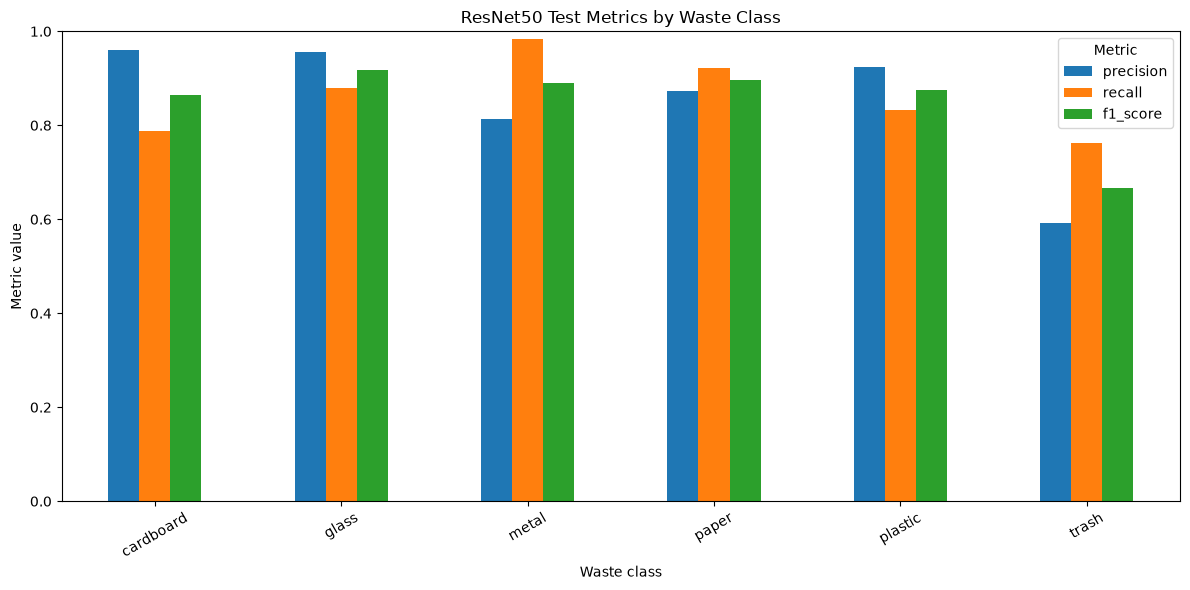

In [ ]:

metric_plot_dataframe = (
    per_class_dataframe
    .set_index("class_name")
    [
        [
            "precision",
            "recall",
            "f1_score",
        ]
    ]
)

metric_plot_dataframe.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title("ResNet50 Test Metrics by Waste Class")
plt.xlabel("Waste class")
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

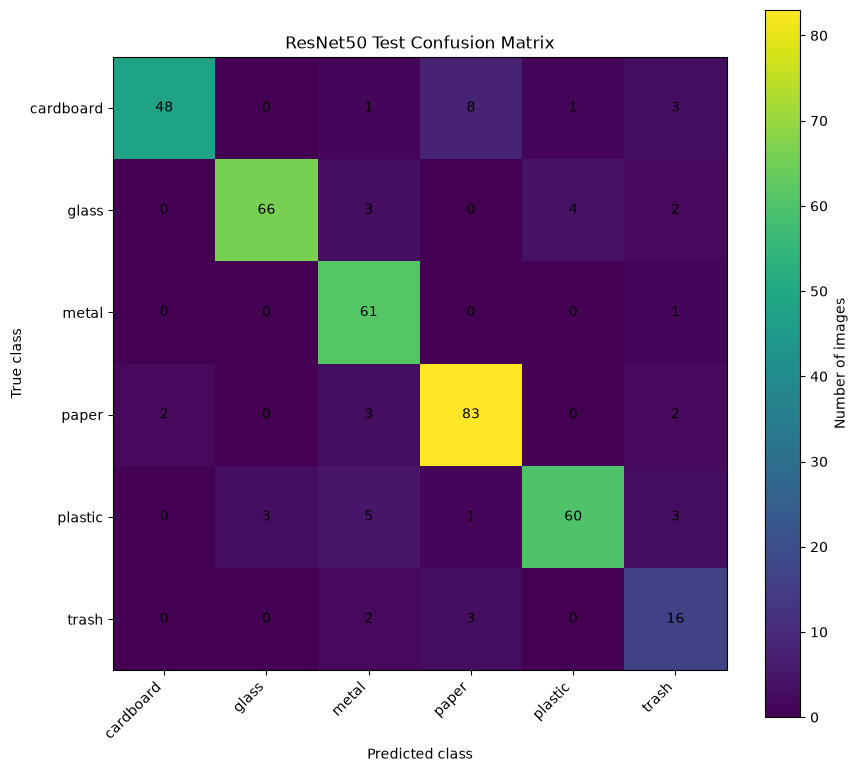

In [47]:
confusion_matrix_values = (
    test_metrics.confusion_matrix
)

figure, axis = plt.subplots(
    figsize=(9, 8),
)

image = axis.imshow(
    confusion_matrix_values
)

axis.set_title("ResNet50 Test Confusion Matrix")
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")

axis.set_xticks(
    range(len(data_bundle.class_names))
)

axis.set_yticks(
    range(len(data_bundle.class_names))
)

axis.set_xticklabels(
    data_bundle.class_names,
    rotation=45,
    ha="right",
)

axis.set_yticklabels(
    data_bundle.class_names
)

for row_index in range(
    confusion_matrix_values.shape[0]
):
    for column_index in range(
        confusion_matrix_values.shape[1]
    ):
        axis.text(
            column_index,
            row_index,
            str(
                confusion_matrix_values[
                    row_index,
                    column_index
                ]
            ),
            ha="center",
            va="center",
        )

figure.colorbar(
    image,
    ax=axis,
    label="Number of images",
)

figure.tight_layout()
plt.show()

In [ ]:
confusion_records = []

for true_index, true_class in enumerate(
    data_bundle.class_names
):
    for predicted_index, predicted_class in enumerate(
        data_bundle.class_names
    ):
        if true_index == predicted_index:
            continue

        confusion_records.append(
            {
                "true_class": true_class,
                "predicted_class": predicted_class,
                "image_count": int(
                    confusion_matrix_values[
                        true_index,
                        predicted_index
                    ]
                ),
            }
        )

confusion_dataframe = (
    pd.DataFrame(confusion_records)
    .sort_values(
        "image_count",
        ascending=False,
    )
    .reset_index(drop=True)
)

confusion_dataframe.head(10)

,true_class,predicted_class,image_count
0,cardboard,paper,8
1,plastic,metal,5
2,glass,plastic,4
3,glass,metal,3
4,paper,metal,3
5,cardboard,trash,3
6,plastic,glass,3
7,plastic,trash,3
8,trash,paper,3
9,trash,metal,2


In [59]:
prediction_summary = (
    test_prediction_dataframe["correct"]
    .value_counts()
    .rename(
        index={
            True: "correct",
            False: "incorrect",
        }
    )
)

prediction_summary

correct
correct      334
incorrect     47
Name: count, dtype: int64

In [61]:
misclassified_dataframe = (
    test_prediction_dataframe[
        ~test_prediction_dataframe["correct"]
    ]
    .sort_values(
        "predicted_confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Total misclassified test images:",
    len(misclassified_dataframe),
)

misclassified_dataframe.head(10)

Total misclassified test images: 47


,image_path,true_index,true_class,predicted_index,predicted_class,predicted_confidence,true_class_probability,correct
0,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,4,plastic,2,metal,0.897900,0.029532,False
1,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,4,plastic,5,trash,0.879579,0.045782,False
2,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,3,paper,0.874602,0.088758,False
3,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,3,paper,0.859853,0.106065,False
4,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,cardboard,3,paper,0.844538,0.081738,False
5,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,4,plastic,1,glass,0.805498,0.095961,False
6,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,4,plastic,5,trash,0.767943,0.005808,False
7,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,1,glass,2,metal,0.695222,0.265377,False
8,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,4,plastic,2,metal,0.653193,0.223700,False
9,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,3,paper,0,cardboard,0.643026,0.345034,False


### High-Confidence Error Analysis

The best ResNet50 checkpoint misclassified **47 of 381 test images**, while correctly classifying **334 images**.

This corresponds to:

```text
Correct predictions:   334
Incorrect predictions: 47
Test accuracy:         87.66%

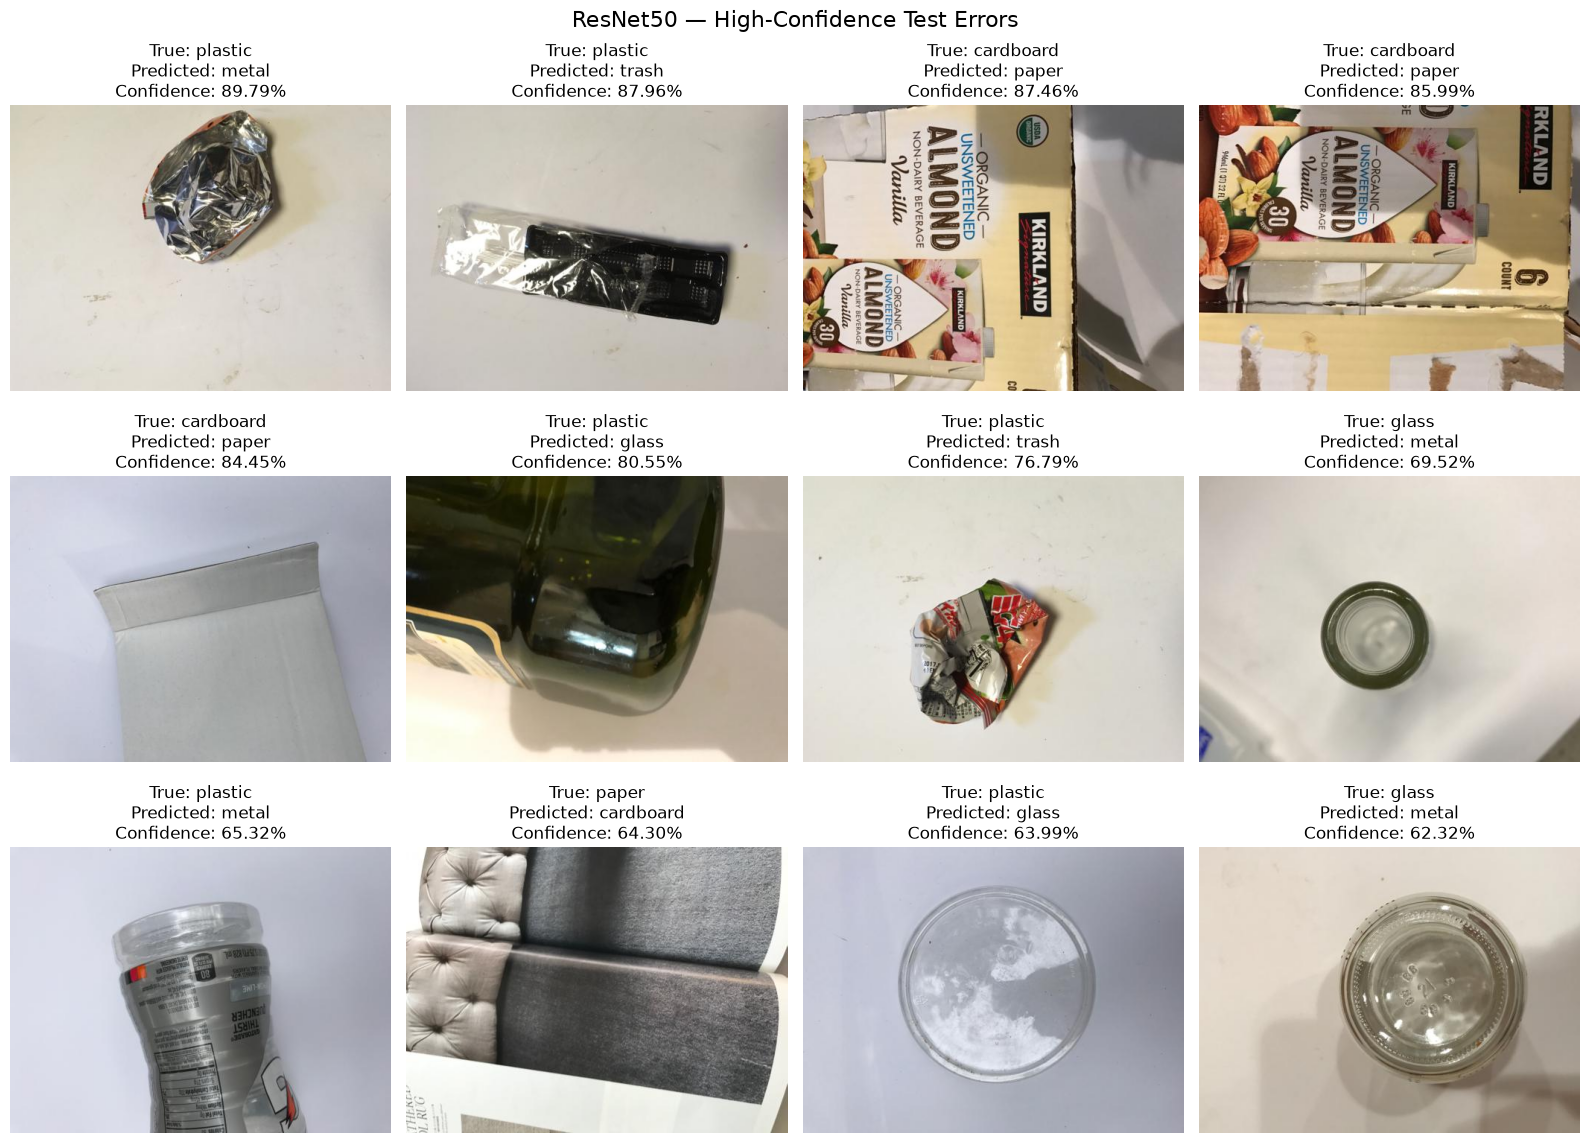

In [63]:
number_of_examples = min(
    12,
    len(misclassified_dataframe),
)

figure, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(16, 12),
)

for axis in axes.flatten():
    axis.axis("off")

for axis, (_, row) in zip(
    axes.flatten(),
    misclassified_dataframe.head(
        number_of_examples
    ).iterrows(),
):
    with Image.open(
        row["image_path"]
    ) as image:
        axis.imshow(
            image.convert("RGB")
        )

    axis.set_title(
        f"True: {row['true_class']}\n"
        f"Predicted: {row['predicted_class']}\n"
        f"Confidence: "
        f"{row['predicted_confidence']:.2%}"
    )

    axis.axis("off")

figure.suptitle(
    "ResNet50 — High-Confidence Test Errors",
    fontsize=16,
)

figure.tight_layout()
plt.show()

In [64]:
baseline_metrics = {
    "model": "baseline_cnn",
    "accuracy": 0.5591,
    "macro_precision": 0.5980,
    "macro_recall": 0.5783,
    "macro_f1": 0.5421,
    "weighted_f1": 0.5680,
    "roc_auc_ovr_macro": 0.8774,
    "average_inference_ms": 42.2821,
}

resnet50_metrics = {
    "model": "resnet50_classifier",
    "accuracy": test_metrics.accuracy,
    "macro_precision": test_metrics.macro_precision,
    "macro_recall": test_metrics.macro_recall,
    "macro_f1": test_metrics.macro_f1,
    "weighted_f1": test_metrics.weighted_f1,
    "roc_auc_ovr_macro": (
        test_metrics.roc_auc_ovr_macro
    ),
    "average_inference_ms": (
        test_metrics
        .average_inference_time_seconds
        * 1000
    ),
}

initial_comparison_dataframe = pd.DataFrame(
    [
        baseline_metrics,
        resnet50_metrics,
    ]
)

initial_comparison_dataframe.round(4)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_macro,average_inference_ms
0,baseline_cnn,0.5591,0.5980,0.5783,0.5421,0.5680,0.8774,42.2821
1,resnet50_classifier,0.8766,0.8532,0.8614,0.8520,0.8781,0.9879,163.0948


## 8. Initial Comparison with the Baseline

ResNet50 achieved a test accuracy of **87.66%**, compared with the baseline CNN's **55.91%**.

Its macro F1-score was **85.20%**, compared with the baseline's **54.21%**.

Its average inference time was **163.09 ms/image**, compared with the baseline's **42.28 ms/image**.

### Performance improvement

ResNet50 improved test accuracy by:

```text
87.66% − 55.91% = 31.75 percentage points

In [65]:
PER_CLASS_PATH = (
    REPORT_DIRECTORY
    / "per_class_metrics.csv"
)

PREDICTIONS_PATH = (
    REPORT_DIRECTORY
    / "test_predictions.csv"
)

CONFUSIONS_PATH = (
    REPORT_DIRECTORY
    / "class_confusions.csv"
)

COMPARISON_PATH = (
    REPORT_DIRECTORY
    / "baseline_comparison.csv"
)

complete_metrics_report = {
    "model_name": MODEL_NAME,
    "training_mode": TRAINING_MODE,
    "checkpoint_epoch": checkpoint["epoch"],
    "validation": validation_metrics.to_dict(),
    "test": test_metrics.to_dict(),
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
}

METRICS_PATH.write_text(
    json.dumps(
        complete_metrics_report,
        indent=2,
    ),
    encoding="utf-8",
)

per_class_dataframe.to_csv(
    PER_CLASS_PATH,
    index=False,
)

test_prediction_dataframe.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

confusion_dataframe.to_csv(
    CONFUSIONS_PATH,
    index=False,
)

initial_comparison_dataframe.to_csv(
    COMPARISON_PATH,
    index=False,
)

print("ResNet50 reports saved successfully.")

ResNet50 reports saved successfully.
